In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from config.plot_settings import *

In [2]:
NODE_SIZE   = 260
NODE_COLOR  = "white"
EDGE_COLOR  = GRAPHITE
NODE_EDGE   = GRAPHITE
LW          = 1.5        # edge linewidth
NODE_LW     = 1.5        # node border linewidth
STEPS       = 3          # number of time steps

In [3]:
def build_nonrecombinant(steps):
    """Binary tree: 2^k nodes at step k, no merging."""
    G = nx.DiGraph()
    pos = {}
    node_id = 0
    prev_level = [node_id]
    G.add_node(node_id)
    xscale = (2 ** steps - 1) / steps if steps else 1
    pos[node_id] = (0, 0)
    node_id += 1

    for t in range(1, steps + 1):
        curr_level = []
        n = len(prev_level)
        ys = [i - (2**t - 1) / 2 for i in range(0, 2**t, 1)]
        for i, parent in enumerate(prev_level):
            for child_idx in range(2):
                child = node_id
                node_id += 1
                G.add_node(child)
                pos[child] = (t * xscale, ys[2 * i + child_idx])
                G.add_edge(parent, child)
                curr_level.append(child)
        prev_level = curr_level
    return G, pos

def build_recombinant(steps):
    """Binomial tree: k+1 nodes at step k, up/down paths merge."""
    G = nx.DiGraph()
    pos = {}
    for t in range(steps + 1):
        for j in range(t + 1):
            nid = (t, j)
            G.add_node(nid)
            y = j - t / 2
            pos[nid] = (t, y)

    for t in range(steps):
        for j in range(t + 1):
            G.add_edge((t, j), (t + 1, j + 1))
            G.add_edge((t, j), (t + 1, j))
    return G, pos

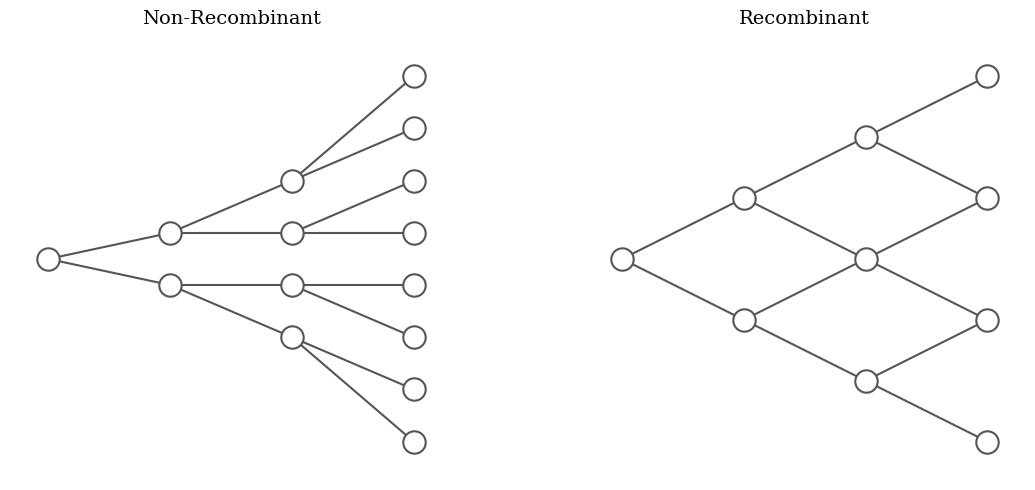

In [4]:
plt.figure(figsize=figsize2)

configs = [
    (build_nonrecombinant(STEPS), 1, "Non-Recombinant"),
    (build_recombinant(STEPS),    2, "Recombinant"),
]

for (G, pos), idx, title in configs:
    ax = plt.subplot(1, 2, idx)
    ax.set_facecolor("white")
    ax.set_aspect("equal")
    ax.axis("off")

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color=EDGE_COLOR,
        width=LW,
        arrows=False,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=NODE_SIZE,
        node_color=NODE_COLOR,
        edgecolors=NODE_EDGE,
        linewidths=NODE_LW,
    )

    ax.set_title(title, fontsize=14, fontfamily="serif", pad=10,
                 fontweight="normal", color="black")

plt.tight_layout()
plt.savefig("../../plots/mathematical_background/tree_illustration.png")
plt.show()